Loading data from C:\Users\Tejas\Desktop\hybrid_recommender\data\processed\cleaned_reviews.csv...
Dataset loaded successfully with 568454 rows.


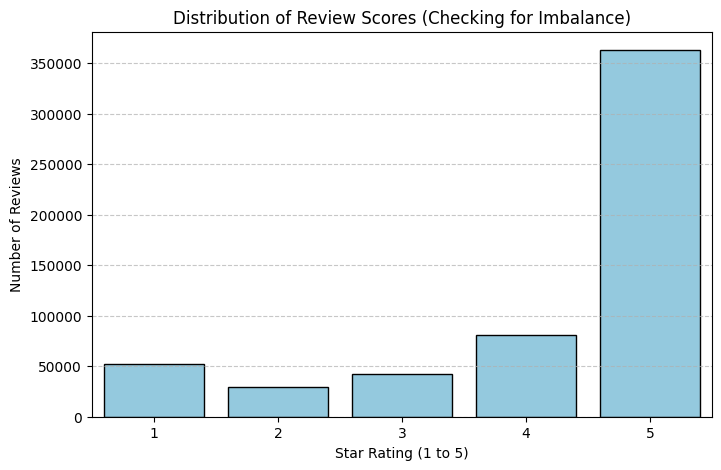

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the cleaned data from Day 1
file_path = r"C:\Users\Tejas\Desktop\hybrid_recommender\data\processed\cleaned_reviews.csv"

print(f"Loading data from {file_path}...")
df = pd.read_csv(file_path)
print(f"Dataset loaded successfully with {len(df)} rows.")

# 2. Plot the distribution of Scores
plt.figure(figsize=(8, 5))
# Using seaborn to create a clean bar chart
sns.countplot(data=df, x='Score', color='skyblue', edgecolor='black')

# Labeling the graph for clarity
plt.title('Distribution of Review Scores (Checking for Imbalance)')
plt.xlabel('Star Rating (1 to 5)')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

Average words: 80
90% of reviews have fewer than: 160 words
95% of reviews have fewer than: 217 words


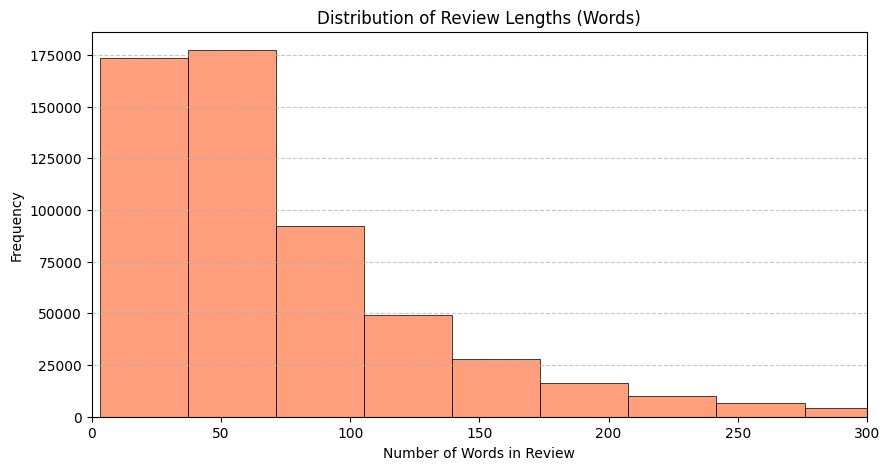

In [2]:
# 1. Calculate the length of each review in words
# We split the string by spaces and count the resulting list
df['review_length'] = df['clean_text'].apply(lambda x: len(str(x).split()))

# 2. Plot the distribution of text lengths
plt.figure(figsize=(10, 5))
# Using histplot for continuous numerical data
sns.histplot(df['review_length'], bins=100, color='coral', edgecolor='black')

# We limit the x-axis to 300 because a few massive 2000-word reviews 
# will skew the visual scale. We only care about the majority.
plt.xlim(0, 300) 

plt.title('Distribution of Review Lengths (Words)')
plt.xlabel('Number of Words in Review')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Calculate crucial percentiles for PyTorch padding
print(f"Average words: {df['review_length'].mean():.0f}")
print(f"90% of reviews have fewer than: {df['review_length'].quantile(0.90):.0f} words")
print(f"95% of reviews have fewer than: {df['review_length'].quantile(0.95):.0f} words")

plt.show()